In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib

# Sklearn & Imblearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, RobustScaler, StandardScaler
)
from sklearn.feature_selection import RFE, SelectKBest, f_classif, f_regression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler, BorderlineSMOTE, SVMSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

 ## 1. Carregamento dos Dados

 Os datasets processados contêm features extraídas de sinais fisiológicos em janelas temporais.
 Cada linha representa uma janela de observação com ~50 features estatísticas e espectrais.

In [ ]:
data_dir = Path.cwd().parent / 'processed' 

df_stress = pd.read_csv(data_dir / 'dataset_stress.csv')
df_exercise = pd.read_csv(data_dir / 'dataset_exercise.csv')

 ## 2. Pré-processamento e Filtragem

 **Exclusão de sujeitos problemáticos**: `f07` e `f13` apresentaram dados inconsistentes
 (possível mau posicionamento do sensor ou artefatos de movimento), comprometendo a qualidade das features.

In [ ]:
exclusoes_stress = ['f07', 'f13']
df_stress_clean = df_stress[~df_stress['subject_id'].isin(exclusoes_stress)].copy()
print(f"Conjunto stress original: {len(df_stress)} \n-> Filtrado: {len(df_stress_clean)} ")

Conjunto stress original: 2317 
-> Filtrado: 2210 


 ## 3. Construção do Dataset Multiclasse

 Para o cenário multiclasse, unificamos os datasets com o seguinte mapeamento de labels:
 - `0` = Repouso
 - `1` = Stress
 - `2` = Aeróbico
 - `3` = Anaeróbico

In [ ]:
df_ex_multi = df_exercise.copy()
df_ex_multi['label'] = df_ex_multi['label'].map({0: 2, 1: 3}) 
cols_comuns = df_stress_clean.columns.intersection(df_ex_multi.columns)
df_multi = pd.concat([df_stress_clean[cols_comuns], df_ex_multi[cols_comuns]], axis=0)

 ## 4. Função Principal de Treinamento

 ### Pipeline implementado:
 1. **Holdout Split** (80/20) estratificado
 2. **Normalização** com `StandardScaler` (z-score)
 3. **Seleção de Features** via RFE com XGBoost como estimador base
 4. **Balanceamento** com SMOTE no conjunto de treino
 5. **Validação Cruzada** 10-Fold estratificada
 6. **Avaliação Final** no conjunto de teste (holdout)

 ### Modelos avaliados:
 - KNN, Logistic Regression, Naive Bayes, SVM, Random Forest, XGBoost

In [ ]:
def ml_pipeline(nome_cenario, df, n_features_alvo, multiclasse=False):

    # 1. Separar X e y
    colunas_meta = ['subject_id', 'window_id', 'label', 'scenario', 'protocol']
    X = df.drop(columns=[c for c in colunas_meta if c in df.columns])
    y = df['label']

    # 2. Holdout 80-20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Feature Selection
    obj = 'multi:softmax' if multiclasse else 'binary:logistic'
    
    selector = RFE(estimator=XGBClassifier(random_state=42, n_jobs=-1), 
                   n_features_to_select=n_features_alvo, step=1)
    selector.fit(X_train_scaled, y_train)
    
    X_train_sel = selector.transform(X_train_scaled)
    X_test_sel = selector.transform(X_test_scaled)
    
    feat_names = X.columns[selector.support_]
    print(f"Melhores Features: {list(feat_names)}")
    
    # 5. Oversampling (SMOTE) Treino
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)
    print(f" SMOTE - Shape de Treinamento: {X_train_res.shape}")

    # Modelos
    models = {
        'KNN': KNeighborsClassifier(),
        'LogReg': LogisticRegression(max_iter=1000),
        'NaiveBayes': GaussianNB(),
        'SVM': SVC(probability=True),
        'RandomForest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    }

    results = []
    
    # 7. Validação Cruzada 10-Fold
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    scoring = {'acc': 'accuracy', 'f1': 'f1_weighted'}
    
    for name, model in models.items():
        # Validação Cruzada nos dados de treino 
        cv_results = cross_validate(model, X_train_res, y_train_res, cv=cv, scoring=scoring)
        
        # Teste Final Holdout
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_sel)
        
        acc_test = accuracy_score(y_test, y_pred)
        f1_test = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            'Model': name,
            'CV_Acc_Mean': cv_results['test_acc'].mean(),
            'CV_F1_Mean': cv_results['test_f1'].mean(),
            'Test_Acc': acc_test,
            'Test_F1': f1_test
        })
        
    return pd.DataFrame(results).sort_values(by='CV_Acc_Mean', ascending=False), feat_names

 ## 5. Comparação de Técnicas de Balanceamento

 O desbalanceamento de classes é comum em dados fisiológicos. Comparamos múltiplas estratégias:

 | Categoria | Técnicas |
 |-----------|----------|
 | **Oversampling** | SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN, RandomOverSampler |
 | **Undersampling** | RandomUnderSampler, TomekLinks, NearMiss |
 | **Híbrido** | SMOTEENN, SMOTETomek |

In [ ]:
def comparar_balanceadores(titulo, df, random_state):
    X = df.drop(columns=['label', 'subject_id', 'window_id'], errors='ignore')
    X = X.select_dtypes(include=[np.number])
    y = df['label']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    
    # Pipeline: Imputar NaN -> Selecionar Features
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(f_classif, k=13))
    ])
    
    X_train_sel = pipeline.fit_transform(X_train, y_train)
    X_test_sel = pipeline.transform(X_test)
    
    # Balanceadores Disponiveis
    balanceadores = {
        "Sem Balanceamento": None,
        "SMOTE": SMOTE(random_state=random_state),
        "BorderlineSMOTE": BorderlineSMOTE(random_state=random_state),
        "SVMSMOTE": SVMSMOTE(random_state=random_state),
        "ADASYN": ADASYN(random_state=random_state, n_neighbors=3),
        "RandomOverSampler": RandomOverSampler(random_state=random_state),
        "RandomUnderSampler": RandomUnderSampler(random_state=random_state),
        "TomekLinks": TomekLinks(),
        "NearMiss": NearMiss(version=1),
        "SMOTEENN": SMOTEENN(random_state=random_state),
        "SMOTETomek": SMOTETomek(random_state=random_state)
    }
    
    model = RandomForestClassifier(n_estimators=100, random_state=random_state)
    resultados = []
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    for nome_bal, bal in balanceadores.items():
        try:
            # balanceador
            if bal is None:
                X_res, y_res = X_train_sel, y_train
            else:
                X_res, y_res = bal.fit_resample(X_train_sel, y_train)
            
            # Validação Cruzada
            scores = cross_validate(model, X_res, y_res, cv=cv, scoring='accuracy')
            
            resultados.append({
                'Balanceador': nome_bal,
                'Acurácia Média': scores['test_score'].mean(),
                'Std': scores['test_score'].std(),
                'Amostras Treino': len(y_res)
            })
            
        except ValueError as e:
            print(f"{nome_bal}: {str(e)}")
            resultados.append({
                'Balanceador': nome_bal,
                'Acurácia Média': np.nan,
                'Std': np.nan,
                'Amostras Treino': np.nan
            })
    
    return pd.DataFrame(resultados).sort_values('Acurácia Média', ascending=False)

 ## 6. Execução dos Experimentos

 ### 6.1 Classificação Binária: Stress vs Repouso
 - **Features selecionadas**: 13
 - **Expectativa**: Alta performance devido à distinção clara nos padrões de EDA e HRV

In [ ]:
res_stress, feat_stress = ml_pipeline("Classificação Stress/Repouso", df_stress_clean, 13)
display(res_stress)

Melhores Features: ['bvp_std', 'acc_x_mean', 'acc_y_mean', 'acc_mean', 'acc_std', 'acc_ratio_down', 'mean_raw_eda', 'std_tonic_eda', 'scr_mean_amp', 'scr_mean_height', 'hr_mean', 'mean_ibi', 'pnn20']
 SMOTE - Shape de Treinamento: (1858, 13)


,Model,CV_Acc_Mean,CV_F1_Mean,Test_Acc,Test_F1
4,RandomForest,0.833139,0.832782,0.832579,0.832675
5,XGBoost,0.825062,0.824759,0.846154,0.846154
0,KNN,0.753999,0.753499,0.780543,0.780567
3,SVM,0.671671,0.670458,0.726244,0.726054
1,LogReg,0.608730,0.607656,0.567873,0.568062
2,NaiveBayes,0.573173,0.533361,0.558824,0.523241


 ### 6.2 Classificação Binária: Aeróbico vs Anaeróbico
 - **Features selecionadas**: 12
 - **Desafio**: Ambos envolvem ativação simpática, diferença está na intensidade e padrão temporal

In [ ]:
res_ex, feat_ex = ml_pipeline("Classificação Aeróbico/Anaeróbico", df_exercise, 12)
display(res_ex)

Melhores Features: ['bvp_std', 'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mean', 'mean_raw_eda', 'std_tonic_eda', 'LF_power', 'HF_n']
 SMOTE - Shape de Treinamento: (2340, 12)


,Model,CV_Acc_Mean,CV_F1_Mean,Test_Acc,Test_F1
4,RandomForest,0.993590,0.993590,0.981053,0.981022
5,XGBoost,0.990171,0.990171,0.985263,0.985255
0,KNN,0.930342,0.930310,0.915789,0.915958
3,SVM,0.872650,0.872502,0.848421,0.849373
1,LogReg,0.678205,0.677923,0.652632,0.657056
2,NaiveBayes,0.546581,0.443899,0.454737,0.364040


 ### 6.3 Classificação Multiclasse (4 classes)
 - **Features selecionadas**: 19
 - **Desafio**: Maior complexidade; classes de exercício podem ser confundidas com stress

In [ ]:
res_multi, feat_multi = ml_pipeline("Classificação Multi-Classe", df_multi, 19, multiclasse=True)
display(res_multi)

Melhores Features: ['bvp_std', 'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mean', 'acc_std', 'acc_ratio_up', 'acc_ratio_down', 'mean_raw_eda', 'std_raw_eda', 'scr_mean_amp', 'scr_mean_height', 'max_ibi', 'min_ibi', 'mean_ibi', 'hr_mean_ibi']
 SMOTE - Shape de Treinamento: (4680, 19)


,Model,CV_Acc_Mean,CV_F1_Mean,Test_Acc,Test_F1
5,XGBoost,0.928205,0.927967,0.920393,0.920609
4,RandomForest,0.924786,0.924530,0.908397,0.908213
0,KNN,0.851496,0.850765,0.803708,0.803696
3,SVM,0.772436,0.771591,0.767721,0.768051
1,LogReg,0.621581,0.620139,0.615049,0.616655
2,NaiveBayes,0.517735,0.460554,0.477644,0.431264


 ### 6.4 Análise Comparativa de Balanceadores
 Avaliação do impacto de diferentes técnicas de balanceamento na classificação de stress.

In [ ]:
res_bal_stress = comparar_balanceadores("Stress - Impacto Balanceadores", df_stress_clean, 13)
display(res_bal_stress)

ADASYN: No samples will be generated with the provided ratio settings.


,Balanceador,Acurácia Média,Std,Amostras Treino
9,SMOTEENN,0.854439,0.035871,632.0
10,SMOTETomek,0.768409,0.037083,1628.0
1,SMOTE,0.759427,0.030397,1858.0
5,RandomOverSampler,0.755135,0.024820,1858.0
7,TomekLinks,0.753228,0.038701,1633.0
3,SVMSMOTE,0.751901,0.041397,1858.0
2,BorderlineSMOTE,0.745461,0.030346,1858.0
8,NearMiss,0.736555,0.038205,1678.0
0,Sem Balanceamento,0.726749,0.040752,1768.0
6,RandomUnderSampler,0.725225,0.027563,1678.0


 ## 7. Visualizações

 ### Funções de visualização implementadas:
 - **Matriz de Confusão**: Com percentuais normalizados por linha
 - **Importância de Features**: Ranking baseado no ganho do XGBoost

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


def plot_custom_confusion_matrix(y_true, y_pred, classes, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_norm[i, j]
            if i == j:
                s = cm.sum(axis=1)[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p * 100, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p * 100, c)
                
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, lw=0.5, ax=ax,
                xticklabels=classes, yticklabels=classes,
                annot_kws={"fontsize": 12, "fontweight": "bold"})
    
    ax.set_title(f"{title}", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Predito', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title, color):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1] # Decrescente
    df_imp = pd.DataFrame({
        'Feature': np.array(feature_names)[indices],
        'Importance': importances[indices]
    })

    fig, ax = plt.subplots(figsize=(10, len(feature_names) * 0.4 + 2))
    sns.barplot(data=df_imp, x='Importance', y='Feature', color=color, ax=ax)
    
    ax.set_title(f"Importância das Features: {title}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Ganho (Importance)')
    ax.set_ylabel('')
    
    for i, v in enumerate(df_imp['Importance']):
        ax.text(v + 0.002, i, f"{v:.3f}", color='black', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


def visualizar_resultado_final(df, features_selecionadas, classes, title, cmap, color, balancer, multiclasse=False):
    # Preparação
    colunas_meta = ['subject_id', 'window_id', 'label', 'scenario', 'protocol']
    X = df.drop(columns=[c for c in colunas_meta if c in df.columns])
    y = df['label']
    
    # Filtra apenas as features que o RFE selecionou
    X = X[features_selecionadas]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Balanceamento
    if balancer:
        X_train_res, y_train_res = balancer.fit_resample(X_train_scaled, y_train)
    else:
        X_train_res, y_train_res = X_train_scaled, y_train
        
    # Treino
    metric = 'mlogloss' if multiclasse else 'logloss'
    model = XGBClassifier(use_label_encoder=False, eval_metric=metric, random_state=42, n_estimators=200)
    model.fit(X_train_res, y_train_res)
    
    # Predição
    y_pred = model.predict(X_test_scaled)
    
    # Plots
    plot_custom_confusion_matrix(y_test, y_pred, classes, title, cmap)
    plot_feature_importance(model, features_selecionadas, title, color)

 ## 8. Resultados Visuais por Cenário

 ### 8.1 Stress vs Repouso
 Modelo final: XGBoost com SMOTE

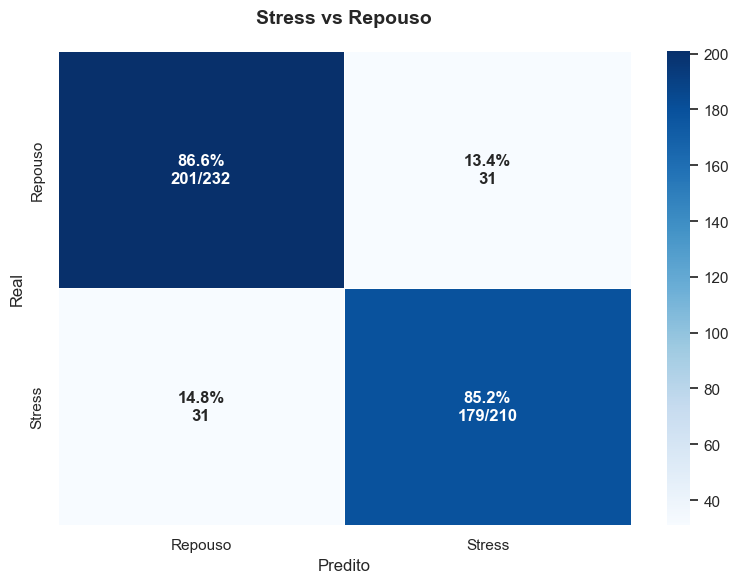

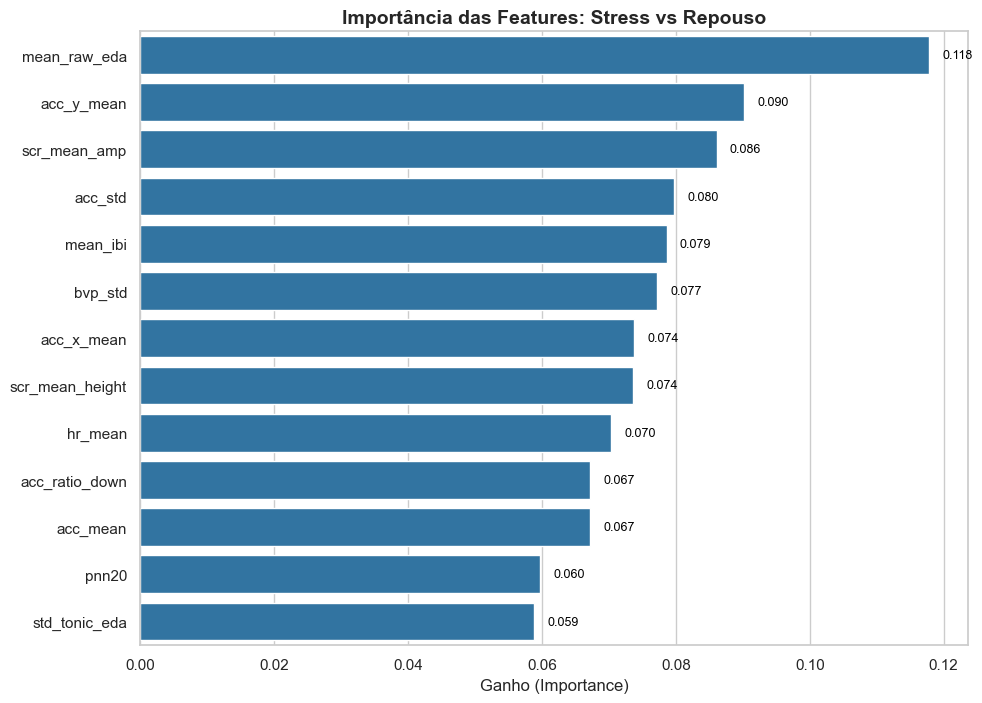

In [ ]:
visualizar_resultado_final(
    df_stress_clean, 
    feat_stress, 
    classes=['Repouso', 'Stress'], 
    title="Stress vs Repouso", 
    cmap='Blues', 
    color='#1f77b4',
    balancer=SMOTE(random_state=42)
)

 ### 8.2 Aeróbico vs Anaeróbico

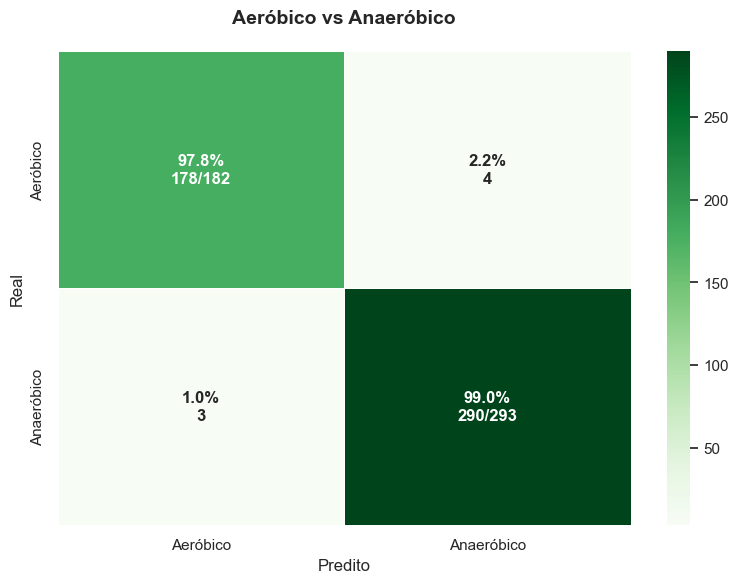

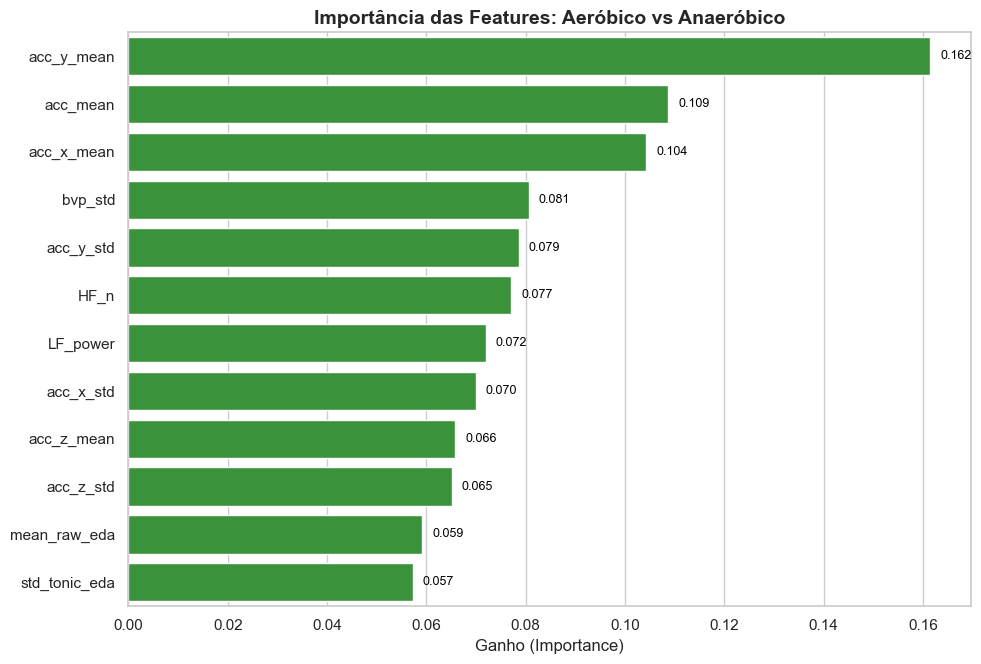

In [ ]:
visualizar_resultado_final(
    df_exercise, 
    feat_ex, 
    classes=['Aeróbico', 'Anaeróbico'], 
    title="Aeróbico vs Anaeróbico", 
    cmap='Greens', 
    color='#2ca02c',
    balancer=SMOTE(random_state=42)
)

 ### 8.3 Classificação Multiclasse

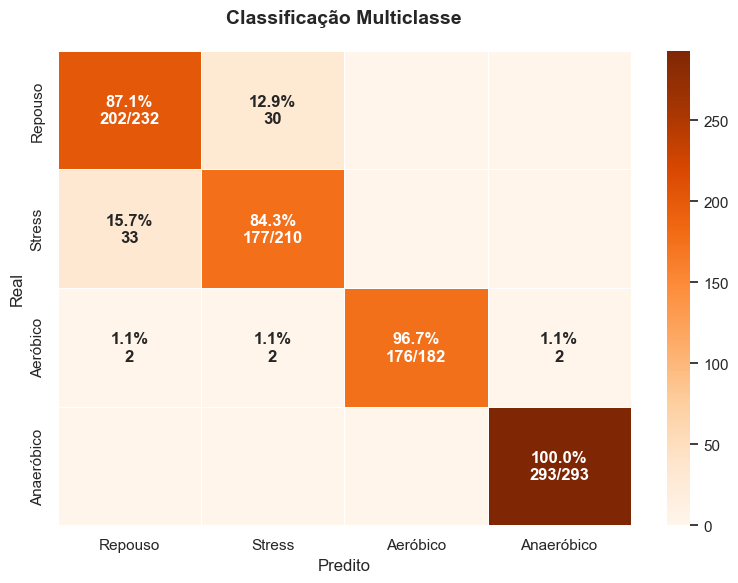

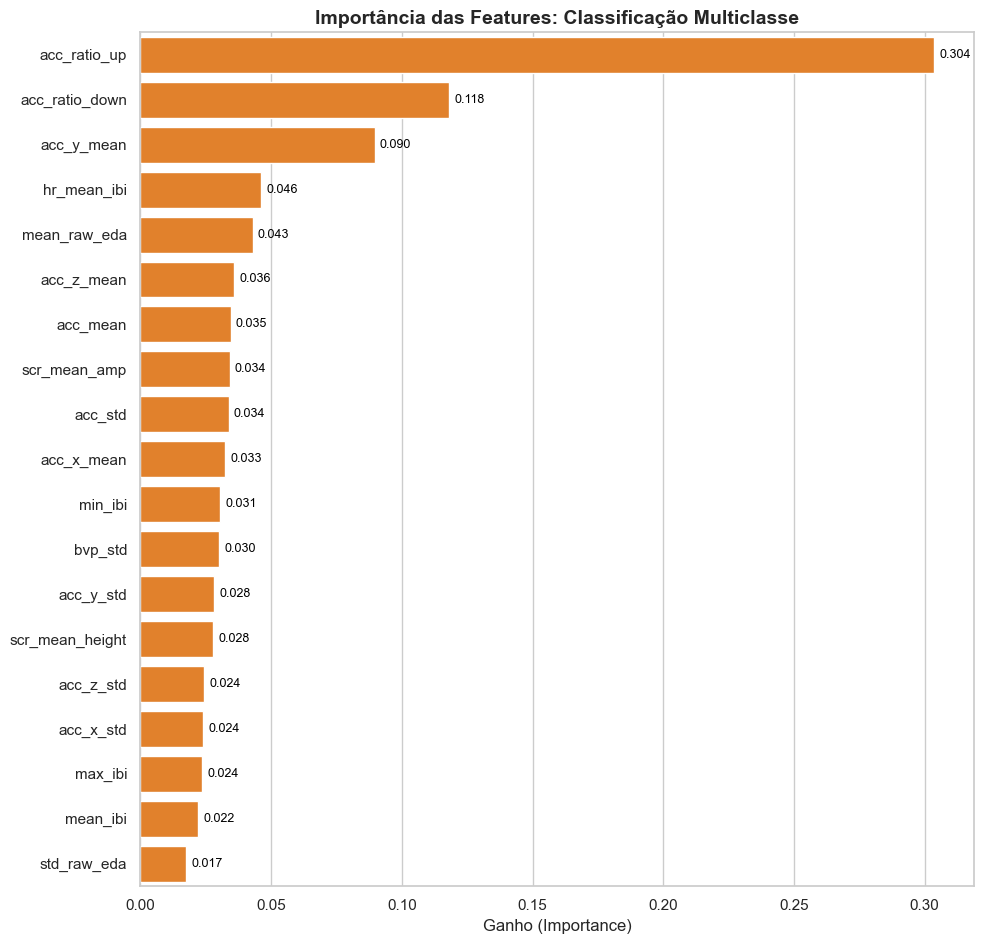

In [ ]:
visualizar_resultado_final(
    df_multi, 
    feat_multi, 
    classes=['Repouso', 'Stress', 'Aeróbico', 'Anaeróbico'], 
    title="Classificação Multiclasse", 
    cmap='Oranges', 
    color='#ff7f0e',
    balancer=SMOTE(random_state=42),
    multiclasse=True
)

 ## 9. Persistência dos Modelos

 Os melhores modelos são serializados com `joblib` para uso em produção/inferência.

 **Artefatos salvos por modelo:**
 - `*_model.joblib`: Modelo XGBoost treinado
 - `*_scaler.joblib`: StandardScaler ajustado
 - `*_features.joblib`: Lista de features selecionadas pelo RFE

 > **Para inferência**: Carregar os 3 artefatos e aplicar na ordem:
 > `features → scaler.transform() → model.predict()`

 ### Salvamento Final dos Modelos

 | Modelo | Balanceador | Arquivo |
 |--------|-------------|---------|
 | Stress vs Repouso | SMOTE | `stress_vs_rest_*` |
 | Aeróbico vs Anaeróbico | SMOTE | `aerobic_vs_anaerobic_*` |
 | Multiclasse | SMOTE | `multiclass_*` |

In [ ]:
def salvar_melhor_modelo(df, features_selecionadas, nome_arquivo, balancer=None, multiclasse=False):
    """Treina e salva o melhor modelo (XGBoost) com joblib"""
    
    # Preparação
    colunas_meta = ['subject_id', 'window_id', 'label', 'scenario', 'protocol']
    X = df.drop(columns=[c for c in colunas_meta if c in df.columns])
    y = df['label']
    
    # Filtrar features selecionadas
    X = X[features_selecionadas]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Balanceamento
    if balancer:
        X_train_res, y_train_res = balancer.fit_resample(X_train_scaled, y_train)
    else:
        X_train_res, y_train_res = X_train_scaled, y_train
    
    # Treinar modelo
    metric = 'mlogloss' if multiclasse else 'logloss'
    model = XGBClassifier(
        use_label_encoder=False, 
        eval_metric=metric, 
        random_state=42, 
        n_estimators=200
    )
    model.fit(X_train_res, y_train_res)
    
    # Criar diretório se não existir
    models_dir = Path(r'C:\DEV\mestrado\WSD\experiments\models')
    models_dir.mkdir(parents=True, exist_ok=True)
    
    # Salvar modelo e scaler
    modelo_path = models_dir / f'{nome_arquivo}_model.joblib'
    scaler_path = models_dir / f'{nome_arquivo}_scaler.joblib'
    features_path = models_dir / f'{nome_arquivo}_features.joblib'
    
    joblib.dump(model, modelo_path)
    joblib.dump(scaler, scaler_path)
    joblib.dump(list(features_selecionadas), features_path)
    
    # Métricas no conjunto de teste
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"✅ Modelo salvo: {modelo_path}")
    print(f"   Acurácia: {acc:.4f} | F1-Score: {f1:.4f}")
    
    return model, scaler



# 1. Stress vs Repouso (SMOTE)
modelo_stress, scaler_stress = salvar_melhor_modelo(
    df_stress_clean, 
    feat_stress, 
    'stress_vs_rest',
    balancer=SMOTE(random_state=42)
)

modelo_exercise, scaler_exercise = salvar_melhor_modelo(
    df_exercise, 
    feat_ex, 
    'aerobic_vs_anaerobic',
    balancer=SMOTE(random_state=42)
)

modelo_multi, scaler_multi = salvar_melhor_modelo(
    df_multi, 
    feat_multi, 
    'multiclass',
    balancer=SMOTE(random_state=42),
    multiclasse=True
)

✅ Modelo salvo: C:\DEV\mestrado\WSD\experiments\models\stress_vs_rest_model.joblib
   Acurácia: 0.8597 | F1-Score: 0.8597
✅ Modelo salvo: C:\DEV\mestrado\WSD\experiments\models\aerobic_vs_anaerobic_model.joblib
   Acurácia: 0.9853 | F1-Score: 0.9853
✅ Modelo salvo: C:\DEV\mestrado\WSD\experiments\models\multiclass_model.joblib
   Acurácia: 0.9248 | F1-Score: 0.9250


 ## 10. Conclusões

 ### Principais achados:
 1. **XGBoost** consistentemente apresentou melhor performance nos três cenários
 2. **SMOTE** o experimento conseguiu replicar o mesmo balanceamento
 3. **Features de HRV** (rmssd, sdnn, pnn50) foram predominantes na classificação de stress
 4. **Features de ACC** tiveram maior peso na distinção entre tipos de exercício

 ### Limitações:
 - Dataset relativamente pequeno (~2300 amostras)
 - Validação intra-sujeito
 - Possível data leakage temporal entre janelas adjacentes

 ### Trabalhos Futuros:
 - Implementar validação Leave-One-Subject-Out (LOSO)
 - Explorar modelos de deep learning (LSTM, Transformer)
 - Refinar features de domínio de frequência